# 03 — CNN desde cero (Keras y PyTorch)

**Qué hace:** entrena dos CNN construidas desde cero sobre imágenes a 128px, en paralelo con dos frameworks: una en Keras (`modeloOne`, con `image_dataset_from_directory` y data augmentation) y otra en PyTorch (`RedNeuronal`, con `ResizeConPadding` para conservar la proporción, un bucle de entrenamiento manual con early stopping y evaluación final en test).

**Consume:** `asl_split_nuevo/train|test|validate/<clase>/*` (producido por `02_split_por_grupos.ipynb`).

**Produce:** `mejor_modelo.pth` (mejores pesos del modelo PyTorch, guardado durante el entrenamiento). El modelo Keras no se guarda a disco en esta sección.

## Imports y rutas base

In [ ]:
from pathlib import Path


In [2]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import regularizers, layers

In [3]:
DESTINO = Path('./asl_split_nuevo')   
train_dir = DESTINO / 'train'
test_dir = DESTINO / 'test'
val_dir = DESTINO / 'validate'

## Vista previa de una imagen del split

Leyendo: asl_split_nuevo/train/R/P3_R_263.jpg


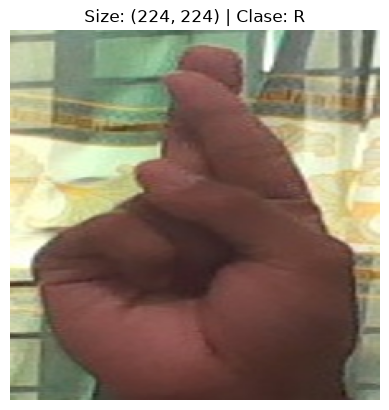

In [5]:
#from PIL import Image
import matplotlib.pyplot as plt
#from pathlib import Path

SIZE = (224, 224)

# Primera imagen que encuentre en train
img_path = next(train_dir.rglob('*.jpg'))  # o '*.png'
print(f"Leyendo: {img_path}")

img = Image.open(img_path).resize(SIZE)

plt.imshow(img)
plt.title(f"Size: {img.size} | Clase: {img_path.parent.name}")
plt.axis('off')
plt.show()


## Carga de datos a 128px con `image_dataset_from_directory`

In [55]:
trained_generated = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(128, 128),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

Found 8620 files belonging to 36 classes.


In [56]:
validation_generated = image_dataset_from_directory(
    val_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(128, 128),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

Found 12267 files belonging to 36 classes.


In [57]:
test_generated = image_dataset_from_directory(
    test_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(128, 128),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

Found 14517 files belonging to 36 classes.


## Definición y entrenamiento del CNN en Keras

In [65]:

modeloOne = tf.keras.models.Sequential([
    ## entrada de datos
    layers.Input(shape=(128,128,3)),
    ## data augmentatio
    ##layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    ## normalización
    layers.Rescaling(1/255),
    ## bloque cnn, pocos filtros detecta bordes
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    ## bloque cnn, mas filtros detecta formas
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    #bloque cnn, mas filtros detecta partes de la mano
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-5), activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(trained_generated.class_names), activation='softmax')
])

In [66]:
modeloOne.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,404 (446.89 KB)

 Trainable params: 114,404 (446.89 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
modeloOne.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001), loss="categorical_crossentropy", metrics=['accuracy', 'precision', 'recall'])

In [68]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [70]:
earlyStopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True 
)

In [71]:
historyOne = modeloOne.fit(
    trained_generated,
    epochs=30,
    validation_data=validation_generated,
    callbacks=[earlyStopping]
) 

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.0867 - loss: 3.5039 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0097 - val_loss: 3.7026 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.1260 - loss: 3.1731 - precision: 0.6279 - recall: 0.0031 - val_accuracy: 0.0878 - val_loss: 3.2728 - val_precision: 0.1731 - val_recall: 0.0040
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.1781 - loss: 2.7820 - precision: 0.5518 - recall: 0.0229 - val_accuracy: 0.1475 - val_loss: 2.8600 - val_precision: 0.5061 - val_recall: 0.0440
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.2135 - loss: 2.5645 - precision: 0.5606 - recall: 0.0386 - val_accuracy: 0.1687 - val_loss: 2.7096 - val_precision: 0.4520 - val_recall: 0.0526
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.2601 - loss: 2.3944 - precision: 0.6519 - recall: 0.0630 - val_accuracy: 0.1903 - v

In [72]:
evalution = modeloOne.evaluate(test_generated)
print(evalution)

146/146 ━━━━━━━━━━━━━━━━━━━━ 80s 551ms/step - accuracy: 0.3618 - loss: 2.6249 - precision: 0.4561 - recall: 0.2317
[2.624937057495117, 0.3617827296257019, 0.45606184005737305, 0.2316594272851944]


## CNN en PyTorch: definición del modelo (`RedNeuronal`)

In [5]:
import torch
import torch.nn as nn

class RedNeuronal(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.blockOne = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.blockTwo = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.blockThree = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.poolGlobal = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64), ## Dense(128)
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_class)
        )

    def forward(self, x):
        x = self.blockOne(x)
        x = self.blockTwo(x)
        x = self.blockThree(x)
        x = self.poolGlobal(x)
        x = self.classifier(x)
        return x

## `ResizeConPadding`: redimensiona conservando proporción y rellena a cuadrado

In [11]:
from PIL import Image
import torchvision.transforms.functional as F

class ResizeConPadding:
    """Redimensiona conservando proporción y rellena hasta un cuadrado."""
    def __init__(self, tamano):
        self.tamano = tamano

    def __call__(self, img):
        w, h = img.size
        # 1. Escalar el lado más largo hasta 'tamano', manteniendo proporción
        escala = self.tamano / max(w, h)
        nuevo_w, nuevo_h = round(w * escala), round(h * escala)
        img = img.resize((nuevo_w, nuevo_h), Image.BILINEAR)

        # 2. Calcular cuánto relleno falta a cada lado para llegar al cuadrado
        pad_w = self.tamano - nuevo_w
        pad_h = self.tamano - nuevo_h
        # (izquierda, arriba, derecha, abajo) — repartido para centrar
        padding = (pad_w // 2, pad_h // 2,
                   pad_w - pad_w // 2, pad_h - pad_h // 2)

        # 3. Rellenar con negro (0) hasta el cuadrado exacto
        return F.pad(img, padding, fill=0)

## Transforms, datasets y dataloaders de PyTorch

In [10]:
## transform
from torchvision import transforms

transform_train = transforms.Compose([
    ##transforms.Resize((128, 128)),
    ResizeConPadding(128),          # ← en vez de transforms.Resize((128,128))
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor() ## convierte en tensor y normaliza entre 0-1
])

In [8]:
transform_eval = transforms.Compose([
    ##transforms.Resize((128, 128)),
    ResizeConPadding(128),          # ← también aquí
    transforms.ToTensor(),
])

In [13]:
## load data
from torchvision import datasets

train_ds = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_ds = datasets.ImageFolder(root=test_dir, transform=transform_eval)
val_ds = datasets.ImageFolder(root=val_dir, transform=transform_eval)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

In [15]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

mps


In [16]:
modelo = RedNeuronal(len(train_ds.classes)).to(device)
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.AdamW(modelo.parameters(), lr=0.001)

## Funciones de entrenamiento y evaluación por época

In [36]:
## el entrenamiento siempre consiste en 4 pasos 
## borrar gradiente, predecir y calcular error, backward o calcular gradiente, actualizar los pesos

def entrenar_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total, aciertos, total = 0,0,0

    for imagenes, etiquetas in loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        ## los 4 pasos del aprendizaje
        optimizador.zero_grad() ## borrar gradiente
        salidas = modelo(imagenes) ## llamado a foward predecir y calcular error
        perdida = criterio(salidas, etiquetas)
        perdida.backward() ## calcular gradiente
        optimizador.step()


        ## metricas

        perdida_total += perdida.item()
        aciertos += (salidas.argmax(1) == etiquetas).sum().item()
        total += etiquetas.size(0)

    return perdida_total / len(loader), aciertos / total

In [37]:
def evaluar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total, aciertos, total = 0,0,0
    with torch.no_grad(): ## desactivar el gradiente
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_total += perdida.item()
            aciertos += (salidas.argmax(1) == etiquetas).sum().item()
            total += etiquetas.size(0)

    return perdida_total / len(loader), aciertos / total

In [19]:
EPOCAS = 60
PACIENCIA = 5
mejor_val_loss = float('inf')
epocas_sin_mejora = 0

## Bucle de entrenamiento con early stopping manual

In [20]:
for epoca in range(EPOCAS):
    train_loss, train_acc = entrenar_epoca(modelo, train_loader, criterio, optimizador, device)
    val_loss, val_acc = evaluar(modelo, val_loader, criterio, device)

    print(f"Época {epoca+1}: train_acc={train_acc:.3f} loss={train_loss:.3f} | "
          f"val_acc={val_acc:.3f} val_loss={val_loss:.3f}")

    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        torch.save(modelo.state_dict(), 'mejor_modelo.pth') ## guardar el modelo
    else:
        epocas_sin_mejora+=1
        if(epocas_sin_mejora >= PACIENCIA):
            print(f"Early stopping en época {epoca+1}")
            break

modelo.load_state_dict(torch.load('mejor_modelo.pth'))


Época 1: train_acc=0.087 loss=3.494 | val_acc=0.010 val_loss=3.692
Época 2: train_acc=0.121 loss=3.067 | val_acc=0.083 val_loss=3.137
Época 3: train_acc=0.146 loss=2.766 | val_acc=0.098 val_loss=3.001
Época 4: train_acc=0.173 loss=2.639 | val_acc=0.106 val_loss=3.089
Época 5: train_acc=0.204 loss=2.499 | val_acc=0.110 val_loss=2.835
Época 6: train_acc=0.236 loss=2.365 | val_acc=0.117 val_loss=2.708
Época 7: train_acc=0.266 loss=2.236 | val_acc=0.174 val_loss=2.749
Época 8: train_acc=0.294 loss=2.108 | val_acc=0.169 val_loss=2.772
Época 9: train_acc=0.326 loss=2.015 | val_acc=0.168 val_loss=2.595
Época 10: train_acc=0.340 loss=1.957 | val_acc=0.200 val_loss=2.719
Época 11: train_acc=0.378 loss=1.867 | val_acc=0.190 val_loss=2.658
Época 12: train_acc=0.385 loss=1.828 | val_acc=0.190 val_loss=2.569
Época 13: train_acc=0.396 loss=1.798 | val_acc=0.203 val_loss=2.825
Época 14: train_acc=0.406 loss=1.752 | val_acc=0.209 val_loss=2.535
Época 15: train_acc=0.421 loss=1.705 | val_acc=0.195 val_

<All keys matched successfully>

## Evaluación final en test

In [21]:
# Importante: asegúrate de haber restaurado el mejor modelo antes de testear
# (esto ya lo hace tu load_state_dict al final del entrenamiento)
modelo.load_state_dict(torch.load('mejor_modelo.pth'))

# Evaluar en test: misma función, pero con test_loader
test_loss, test_acc = evaluar(modelo, test_loader, criterio, device)

print(f"Test  -> accuracy: {test_acc:.3f} | loss: {test_loss:.3f}")

Test  -> accuracy: 0.314 | loss: 2.476
